<a href="https://colab.research.google.com/github/ydchen17/TwitterAnalysis/blob/main/Twitter_Sentimental_Analysis_(Tesla).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset description

Dataset: [NASDAQ-100 companies twitter](http://www.followthehashtag.com/datasets/nasdaq-100-companies-free-twitter-dataset/) (79 days, from 28 Mar 2016 to 15 Jun 2016) 

I have also uploaded a copy of the data to [my Google Drive](https://drive.google.com/drive/folders/1azP6UOnBhqUBQurhKHNjioycucU0uYLG?usp=sharing). This copy will be used here.

In [3]:
# load Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Bash scripts for batch processing zip files

This is a bash script to save Apple twitter data. Do NOT run this cell for a second time and without necessary modification. The actions taken include:
 1. jump to the working directory 
 2. unzip kike-170k-apple-tweets.zip

In [4]:
# %%bash
# cd /content/drive/MyDrive/DeepLearningProject_StockPrice
# unzip kike-170k-apple-tweets.zip

This is a bash script to process NASDAQ-100 twitter data. Do NOT run this cell for a second time and without necessary modification. The actions taken include:

 1. jump to the working directory 
 2. create a folder named NASDAQ_100_Twitter_Archive
 3. unzip all zip files to the folder NASDAQ_100_Twitter_Archive
 4. jump to the folder
 5. find all zip files in the folder and unzip them to seperate folders
 6. create a folder named compressed
 7. move all zip files into the folder compressed as an archive


In [5]:
# %%bash
# cd /content/drive/MyDrive/DeepLearningProject_StockPrice
# mkdir NASDAQ_100_Twitter_Archive
# unzip NASDAQ_100_Twitter_Archive-A-to-F.zip -d NASDAQ_100_Twitter_Archive
# unzip NASDAQ_100_Twitter_Archive-F-to-X.zip -d NASDAQ_100_Twitter_Archive
# cd NASDAQ_100_Twitter_Archive
# find . -name '*.zip' -exec sh -c 'unzip -d "${1%.*}" "$1"' _ {} \;
# mkdir compressed
# find . -name '*.zip' -exec mv {} compressed \;

# File information extraction

In [6]:
# fetch all zip file names
%%bash
cd /content/drive/MyDrive/DeepLearningProject_StockPrice/NASDAQ_100_Twitter_Archive
ls -a | grep xlsx > files.txt
cat files.txt | head

aal_2016_06_15_12_01_41.xlsx
aapl_2016_06_15_14_30_09.xlsx
adbe_2016_06_15_12_03_58.xlsx
adp_2016_06_15_12_06_34.xlsx
adsk_2016_06_15_12_07_20.xlsx
akam_2016_06_15_12_08_04.xlsx
alxn_2016_06_15_12_08_55.xlsx
amat_2016_06_15_12_09_54.xlsx
amgn_2016_06_15_12_10_36.xlsx
amzn_2016_06_15_12_13_10.xlsx


In [7]:
with open("/content/drive/MyDrive/DeepLearningProject_StockPrice/NASDAQ_100_Twitter_Archive/files.txt", "r") as f:
  files = f.read().split("\n")

# drop NA values
files = [filename for filename in files if filename != ""]
# extract stock code and time stamp
stock_codes = [filename.split("_")[0] for filename in files if filename != ""]
timestamps_sufffixes = [filename.split("_", 1)[1] for filename in files if filename != ""]

# prefix of file paths
prefix = "/content/drive/MyDrive/DeepLearningProject_StockPrice/NASDAQ_100_Twitter_Archive/"

# create all file paths
filepaths = []
for i in range(len(files)):
  filepath = prefix+files[i]+"/export_dashboard_"+stock_codes[i]+"_"+timestamps_sufffixes[i]
  filepaths.append(filepath)

file_zip = dict(zip(stock_codes, filepaths))
# file_zip
# file_zip["aapl"]

# Standardised pipeline scheme

1. load the data
2. data cleaning > indicate dataset size
3. wordcloud visualisation
4. Sentimental analysis 
  
  4.1. Visualise positive sentiments
  
  4.2. Visualise neutral sentiments

  4.3. Visualise negative sentiments

5. LSTM model 
  
  5.1.  data transformation
  
  5.2.  train/test split

  5.3.  model construction

  5.4.  model training and evaluation

  5.4.  result visualisation


In [8]:
# current system information
!uname -a

Linux 4853f7a25879 5.4.104+ #1 SMP Sat Jun 5 09:50:34 PDT 2021 x86_64 x86_64 x86_64 GNU/Linux


In [9]:
# import packages
!pip install emoji
import time
import pandas as pd
import re
import numpy as np
import emoji
import requests
import nltk
import random
nltk.download('punkt')

     |████████████████████████████████| 170 kB 9.1 MB/s 
  Created wheel for emoji: filename=emoji-1.6.1-py3-none-any.whl size=169314 sha256=f87c97c2c9cfe1211af023232b25fdd20395a3417076c38fb4afda0f18ae72b2
  Stored in directory: /root/.cache/pip/wheels/ea/5f/d3/03d313ddb3c2a1a427bb4690f1621eea60fe6f2a30cc95940f
Successfully built emoji
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [10]:
# indicate available files
with open("/content/drive/MyDrive/DeepLearningProject_StockPrice/NASDAQ_100_Twitter_Archive/files.txt", "r") as f:
  files = f.read().split("\n")
# print(files)

# indicate available companies
files = [filename for filename in files if filename != ""]
stock_codes = [filename.split("_")[0].upper() for filename in files if filename != ""]
print(stock_codes)

['AAL', 'AAPL', 'ADBE', 'ADP', 'ADSK', 'AKAM', 'ALXN', 'AMAT', 'AMGN', 'AMZN', 'ATVI', 'AVGO', 'BBBY', 'BIDU', 'BMRN', 'CA', 'CELG', 'CERN', 'CHKP', 'CHTR', 'CMCSA', 'COST', 'CSCO', 'CSX', 'CTRP', 'CTSH', 'DISCA', 'DISCK', 'DISH', 'DLTR', 'EA', 'EBAY', 'ENDP', 'ESRX', 'EXPE', 'FAST', 'FB', 'FISV', 'FOX', 'FOXA', 'GILD', 'GOOG', 'GOOGL', 'HSIC', 'ILMN', 'INCT', 'INCY', 'INTU', 'ISRG', 'JD', 'KHC', 'LBTYA', 'LBTYK', 'LLTC', 'LMCA', 'LMCK', 'LRCX', 'LRCX', 'LVNTA', 'MAR', 'MAT', 'MDLZ', 'MNST', 'MSFT', 'MU', 'MXIM', 'MYL', 'NCLH', 'NFLX', 'NTAP', 'NTES', 'NVDA', 'NXPI', 'ORLY', 'PAYX', 'PCAR', 'PCLN', 'PYPL', 'QCOM', 'QVCA', 'REGN', 'ROST', 'SBAC', 'SBUX', 'SNDK', 'SRCL', 'STX', 'SWKS', 'SYMC', 'TMUS', 'TRIP', 'TSCO', 'TSLA', 'TXN', 'ULTA', 'VIAB', 'VOD', 'VRSK', 'VRTX', 'WBA', 'WDC', 'WFM', 'XLNX', 'YHOO']


In [11]:
# define a function to get information from Alpha Vantage API
def get_stock_information(symbol, function):
  outputsize="full"
  apikey="T6VX725RGZZJFF8P"
  fulllink = "https://www.alphavantage.co/query?function="+function+"&symbol="+symbol+"&outputsize="+outputsize+"&apikey="+apikey
  res = requests.get(fulllink)
  res_json = res.json()
  return res_json

# print(get_stock_information("COST", "OVERVIEW")["Description"])

In [12]:
def path_create():
  code = input("indicate the company code you want to query: ")
  if code.upper() not in stock_codes:
      code = random.choice(stock_codes)
      print("Company code not found! We have randomly chosen "+str(code)+" for you.")
      print("Please rerun the cell if you want to change.\n")
  print(str(get_stock_information(code, "OVERVIEW")["Description"]))
  return code.upper(), file_zip[code.lower()]
code, path = path_create()

indicate the company code you want to query: TSLA
Tesla, Inc. is an American electric vehicle and clean energy company based in Palo Alto, California. Tesla's current products include electric cars, battery energy storage from home to grid-scale, solar panels and solar roof tiles, as well as other related products and services. In 2020, Tesla had the highest sales in the plug-in and battery electric passenger car segments, capturing 16% of the plug-in market (which includes plug-in hybrids) and 23% of the battery-electric (purely electric) market. Through its subsidiary Tesla Energy, the company develops and is a major installer of solar photovoltaic energy generation systems in the United States. Tesla Energy is also one of the largest global suppliers of battery energy storage systems, with 3 GWh of battery storage supplied in 2020.


In [13]:
print(path)

/content/drive/MyDrive/DeepLearningProject_StockPrice/NASDAQ_100_Twitter_Archive/tsla_2016_06_15_14_01_51.xlsx/export_dashboard_tsla_2016_06_15_14_01_51.xlsx


In [14]:
# create a function to indicate the information of data processing based on the file name

def path2info(path):
  company_code = path.split("NASDAQ_100_Twitter_Archive/", 2)[1].split("_")[0]
  current_file = path.split("NASDAQ_100_Twitter_Archive/", 2)[1].split("/",1)[1]

  # extract time into a list and then unpack them 
  d1, d2, d3, d4, d5, d6 = [i for i in current_file.split(".")[0].split("_") if i.isdigit()]
  # pack time in a new format
  create_time = "{}-{}-{} {}:{}:{}".format(d1, d2, d3, d4, d5, d6)

  # print file information 
  print("Currently processing data about "+company_code.upper())
  print("\nCurrent file: "+current_file)
  print("Created at "+create_time)
  print(get_stock_information(company_code.upper(), "OVERVIEW")["Description"])

# path = "/content/drive/MyDrive/DeepLearningProject_StockPrice/NASDAQ_100_Twitter_Archive/aapl_2016_06_15_14_30_09.xlsx/export_dashboard_aapl_2016_06_15_14_30_09.xlsx"
path2info(path)

Currently processing data about TSLA

Current file: export_dashboard_tsla_2016_06_15_14_01_51.xlsx
Created at 2016-06-15 14:01:51
Tesla, Inc. is an American electric vehicle and clean energy company based in Palo Alto, California. Tesla's current products include electric cars, battery energy storage from home to grid-scale, solar panels and solar roof tiles, as well as other related products and services. In 2020, Tesla had the highest sales in the plug-in and battery electric passenger car segments, capturing 16% of the plug-in market (which includes plug-in hybrids) and 23% of the battery-electric (purely electric) market. Through its subsidiary Tesla Energy, the company develops and is a major installer of solar photovoltaic energy generation systems in the United States. Tesla Energy is also one of the largest global suppliers of battery energy storage systems, with 3 GWh of battery storage supplied in 2020.


In [15]:
def load(path):

  # indicate file information
  # indicate current time
  start_time = time.time()
  print(path2info(path))

  # indicate current action
  print("\nLoading the dataset now...")

  try:
    # load the data
    dataset = pd.read_excel(path, "Stream")[["Date", "Hour", "Tweet content"]]

    # indicate starting time
    print("Starting time: "+str(time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(start_time))))
    # indicate finishing time
    print("Finishing time: "+str(time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(time.time()))))
    # indicate execution duration 
    print("Finished within "+str(time.time() - start_time)+"s\n")
    return dataset
  
  except:
    # error message
    print("The dataset cannot be loaded. Execution Aborted!\nPlease check your dataset or path.")
    print("\nStarting time: "+str(time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(start_time))))
    print("Finishing time: "+str(time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(time.time()))))
    print("Finished within "+str(time.time() - start_time)+"s\n")

In [16]:
df = load(path)

Currently processing data about TSLA

Current file: export_dashboard_tsla_2016_06_15_14_01_51.xlsx
Created at 2016-06-15 14:01:51
Tesla, Inc. is an American electric vehicle and clean energy company based in Palo Alto, California. Tesla's current products include electric cars, battery energy storage from home to grid-scale, solar panels and solar roof tiles, as well as other related products and services. In 2020, Tesla had the highest sales in the plug-in and battery electric passenger car segments, capturing 16% of the plug-in market (which includes plug-in hybrids) and 23% of the battery-electric (purely electric) market. Through its subsidiary Tesla Energy, the company develops and is a major installer of solar photovoltaic energy generation systems in the United States. Tesla Energy is also one of the largest global suppliers of battery energy storage systems, with 3 GWh of battery storage supplied in 2020.
None

Loading the dataset now...
Starting time: 2021-10-27 13:36:06
Finis

In [17]:
def check(df):

  # indicate current action
  print("\nChecking the dataset now...")
  start_time = time.time()

  # indicate datas size
  print("\nDataset size: "+str(df.shape))
  
  # check variable types 
  print("\nChecking variables now...")
  print(df.info())
  # print(df.describe())

  # check null valeus  
  print("\nChecking null values now...")
  if df.isnull().sum().any() == 0:
    print("No missing data")
  else:
    print(df.isnull().sum())

  # check duplicated valeus  
  print("\nChecking duplicate values now...")
  if df.duplicated().sum().any() == 0:
    print("No duplicates data")
  else:
    print(df.duplicated().sum())

  # indicate starting time 
  print("Starting time: "+str(time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(start_time))))
  # indicate finishing time
  print("\nFinishing time: "+str(time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(time.time()))))
  # indicate execution duration 
  print("Finished within "+str(time.time() - start_time)+"s\n")

In [18]:
df

,Date,Hour,Tweet content
0,2016-06-15,11:51,$TSLA:\n\nTesla Partners Nordstrom to Open Gal...
1,2016-06-15,11:47,RT @markbspiegel: People really like to be abl...
2,2016-06-15,11:44,Tesla Motors Inc $TSLA Stock Rating Reaffirmed...
3,2016-06-15,11:44,#TeslaMotorsInc Down More Than 10% in One Week...
4,2016-06-15,11:43,Pacific Crest Reiterates “Hold” Rating for Tes...
...,...,...,...
82472,2016-04-02,13:03,$TSLA will be interesting to see how long #bat...
82473,2016-04-02,13:03,$TSLA will be interesting to see how long #bat...
82474,2016-04-02,13:02,RT @stockpulp: This is one of the most relevan...
82475,2016-04-02,12:50,"RT @Lebeaucarnews: Getting 115,000 people to p..."


In [19]:
check(df)


Checking the dataset now...

Dataset size: (82477, 3)

Checking variables now...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82477 entries, 0 to 82476
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           82477 non-null  object
 1   Hour           82477 non-null  object
 2   Tweet content  82477 non-null  object
dtypes: object(3)
memory usage: 1.9+ MB
None

Checking null values now...
No missing data

Checking duplicate values now...
10138
Starting time: 2021-10-27 13:36:23

Finishing time: 2021-10-27 13:36:23
Finished within 0.13102245330810547s



In [20]:
# an ultimate function for data cleaning
def clean(df):

  # indicate current action
  print("Cleaning the data now...")
  start_time = time.time()

  # create new column
  print("Creating a new column with cleaned data...")
  df["cleaned"] = df["Tweet content"].copy()

  # remove @tag and RT
  print("Removing RT and @...")
  df["cleaned"] = df["cleaned"].str.replace("@[\w]*", '', regex=True)
  df["cleaned"] = df["cleaned"].str.replace("RT :", '')

  # remove $ symbol
  print("Removing $ symbol...")
  df["cleaned"] = df["cleaned"].str.replace('$', '')

  # remove #tag
  print("Removing # tag...")
  df["cleaned"] = df["cleaned"].str.replace('#', '')

  # remove url
  print("Removing URLs...")
  df["cleaned"] = df["cleaned"].str.replace('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', regex=True)
  df["cleaned"] = df["cleaned"].str.replace('https', '')
  df["cleaned"] = df["cleaned"].str.replace('http', '')
  
  # remove \n
  print("Removing \\n...")
  df["cleaned"] = df["cleaned"].str.replace('\n', '')
  
  # replace emoji with text
  print("Replacing emojis with texts...")
  df["cleaned"] = df["cleaned"].apply(lambda x: emoji.demojize(x))
  # df["cleaned"] = df["cleaned"].apply(lambda x: " ".join(emoji.demojize(x).split("_")))
  
  # remove empty string
  print("Removing empty strings...")
  df["cleaned"] = df["cleaned"].str.strip(' ')
  df["cleaned"] = df["cleaned"].replace(r'^\s*$', np.NaN, regex=True)
  
  # remove 's mark
  print("Removing quotation marks...")
  df["cleaned"] = df["cleaned"].str.strip('"')
  df["cleaned"] = df["cleaned"].str.strip("'")

  # indicate starting time 
  print("\nStarting time: "+str(time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(time.time()))))
  # indicate finishing time
  print("Finishing time: "+str(time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(time.time()))))
  # indicate execution duration 
  print("Finished within "+str(time.time() - start_time)+"s\n")
  
  # checking dataset again
  check(df)

  return df.dropna()

In [21]:
cleaned_df = clean(df)
# cleaned_df.head(10)

Cleaning the data now...
Creating a new column with cleaned data...
Removing RT and @...
Removing $ symbol...
Removing # tag...
Removing URLs...
Removing \n...
Replacing emojis with texts...
Removing empty strings...
Removing quotation marks...

Starting time: 2021-10-27 13:36:59
Finishing time: 2021-10-27 13:36:59
Finished within 35.15588355064392s


Checking the dataset now...

Dataset size: (82477, 4)

Checking variables now...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82477 entries, 0 to 82476
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           82477 non-null  object
 1   Hour           82477 non-null  object
 2   Tweet content  82477 non-null  object
 3   cleaned        82477 non-null  object
dtypes: object(4)
memory usage: 2.5+ MB
None

Checking null values now...
No missing data

Checking duplicate values now...
10138
Starting time: 2021-10-27 13:36:59

Finishing time: 2021-10-27 13:36:

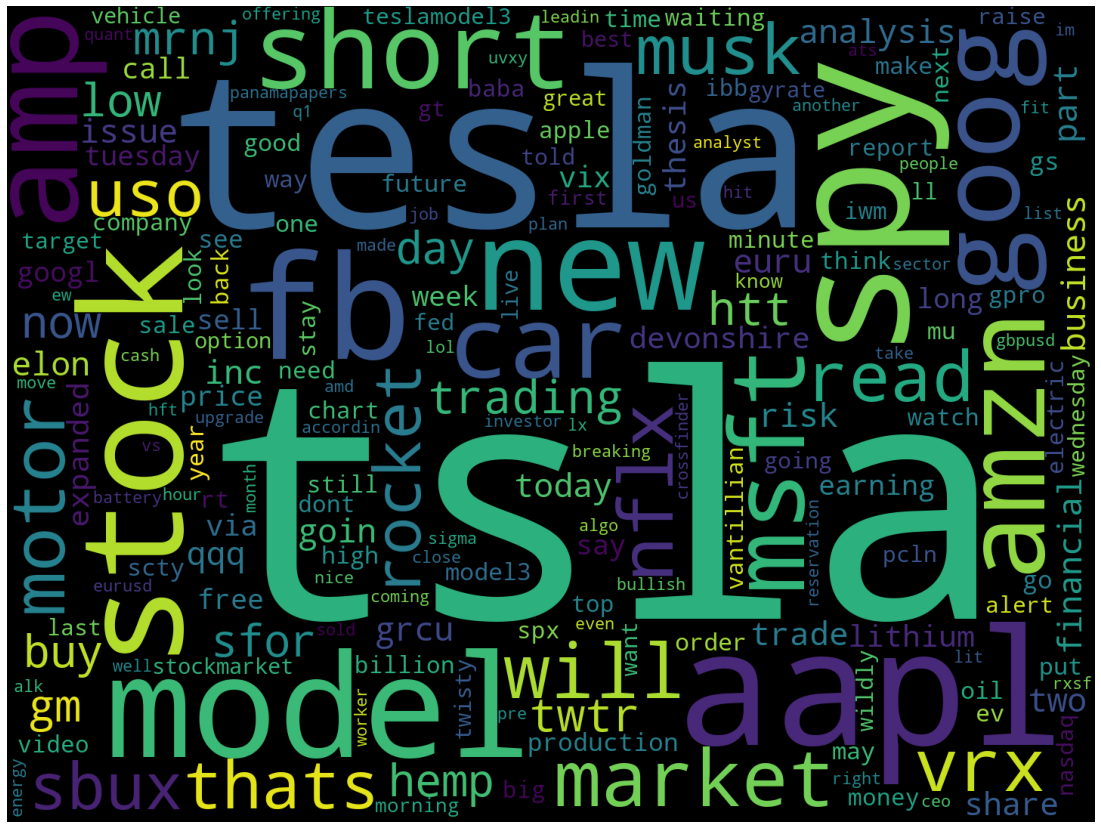

In [22]:
# finally, we can visualise the tweet with a word cloud to get an overview
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def wc_plot(df):
  word_list = str(df["cleaned"].str.lower().tolist()).replace("'","")
  cloud = WordCloud(width=1440, height=1080, collocations=False).generate(word_list)
  plt.figure(figsize=(20, 15))
  plt.imshow(cloud)
  plt.axis('off')

wc_plot(cleaned_df)

## Valence Aware Dictionary for Sentiment Reasoning (VADER) based sentimental classification

VADER is actually a classifier based on vocubulary. You can read [here](https://medium.com/@piocalderon/vader-sentiment-analysis-explained-f1c4f9101cd9) for more detail. Simply put, VADER uses dictionaries showing the emotion of different words, which is rated by human raters from Amazon Mechanical Turk. Punctuation, capitalisation, degree modification, polarity shift due to conjunctions, catching polarity negation are also taken into consideration when rating a sentence with VADER.

In [23]:
def sentiment_class(score):
    """
    Labels each tweet based on its sentiment score
    """
    if score > 0:
        score = "POSITIVE"
    elif score < 0:
        score ='NEGATIVE'
    else:
        score = 'NEUTRAL'
    return score

In [24]:
%%capture
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

def get_VADER_scores(df):

  # Instantiating the sentiment analyzer
  sid = SentimentIntensityAnalyzer()
  
  # Grabbing the sentiment scores and assigning them to a new column
  df['VADER_score'] = [sid.polarity_scores(df['cleaned'].iloc[i])['compound'] for i in range(len(df['cleaned']))]

  # Labeling the tweets in a new column
  df['VADER_class'] = df["VADER_score"].apply(sentiment_class)

  return df

In [25]:
df = get_VADER_scores(df)
df.head()

,Date,Hour,Tweet content,cleaned,VADER_score,VADER_class
0,2016-06-15,11:51,$TSLA:\n\nTesla Partners Nordstrom to Open Gal...,TSLA:Tesla Partners Nordstrom to Open Gallery ...,0.0000,NEUTRAL
1,2016-06-15,11:47,RT @markbspiegel: People really like to be abl...,People really like to be able to go 20-30 mile...,0.6901,POSITIVE
2,2016-06-15,11:44,Tesla Motors Inc $TSLA Stock Rating Reaffirmed...,Tesla Motors Inc TSLA Stock Rating Reaffirmed ...,0.0000,NEUTRAL
3,2016-06-15,11:44,#TeslaMotorsInc Down More Than 10% in One Week...,TeslaMotorsInc Down More Than 10% in One Week ...,0.0000,NEUTRAL
4,2016-06-15,11:43,Pacific Crest Reiterates “Hold” Rating for Tes...,Pacific Crest Reiterates “Hold” Rating for Tes...,0.0000,NEUTRAL


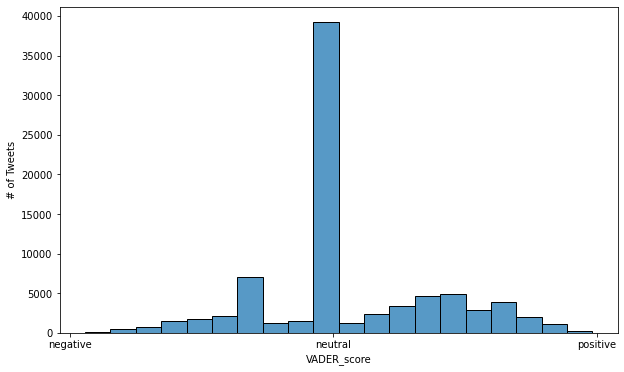

In [26]:
# let's see how accurate this might be.
import seaborn as sns
fig, ax = plt.subplots(figsize=(10,6))
sns.histplot(df["VADER_score"], bins=20)
ax.set_xticks([-1,0,1])
ax.set_xticklabels(['negative', 'neutral', 'positive'])
plt.ylabel("# of Tweets")
plt.show()

NEUTRAL     38506
POSITIVE    26823
NEGATIVE    17148
Name: VADER_class, dtype: int64


Text(0, 0.5, '% of Tweets')

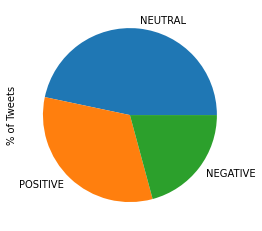

In [27]:
print(df["VADER_class"].value_counts())
df["VADER_class"].value_counts().plot(kind="pie")
plt.ylabel("% of Tweets")

### Visualisation of Positve Sentiments

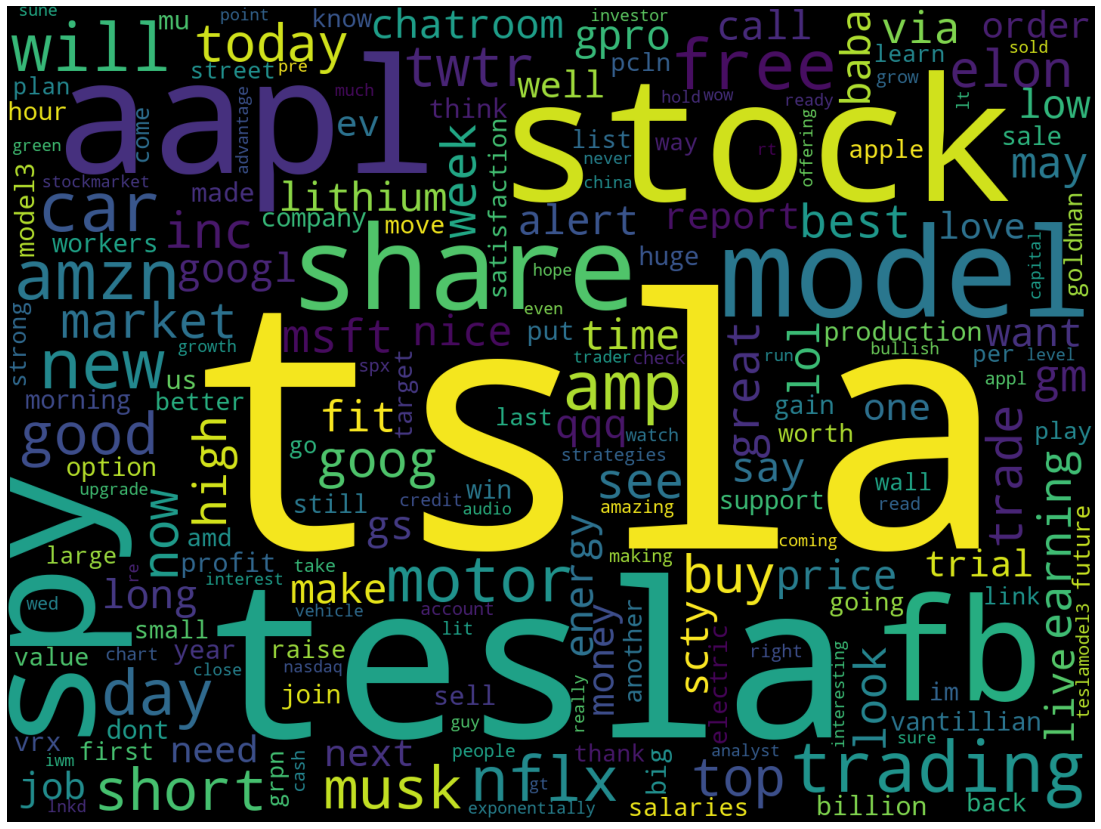

In [28]:
# let's visualise positive, neutral, negative sentiment suggested by VADER with word cloud.
wc_plot(df[df["VADER_class"] == "POSITIVE"])

### Visualisation of Neutral Sentiments

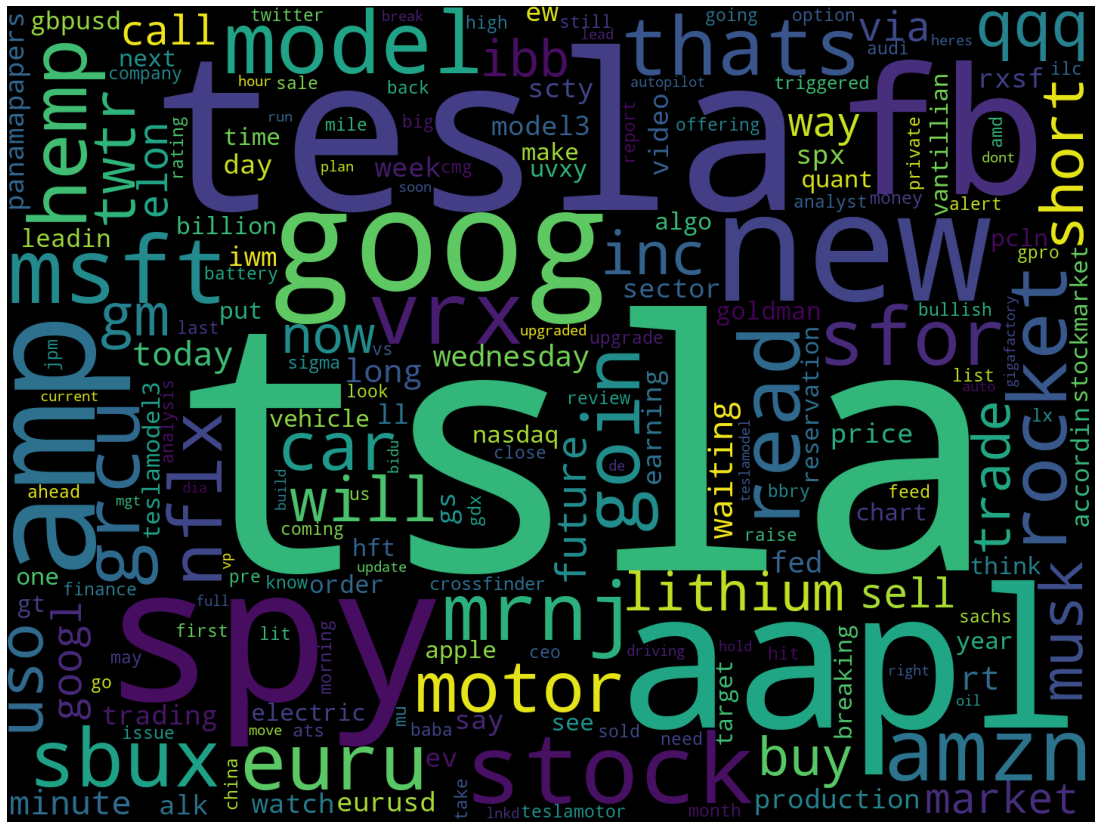

In [29]:
wc_plot(df[df["VADER_class"] == "NEUTRAL"])

### Visualisation of Negative Sentiments

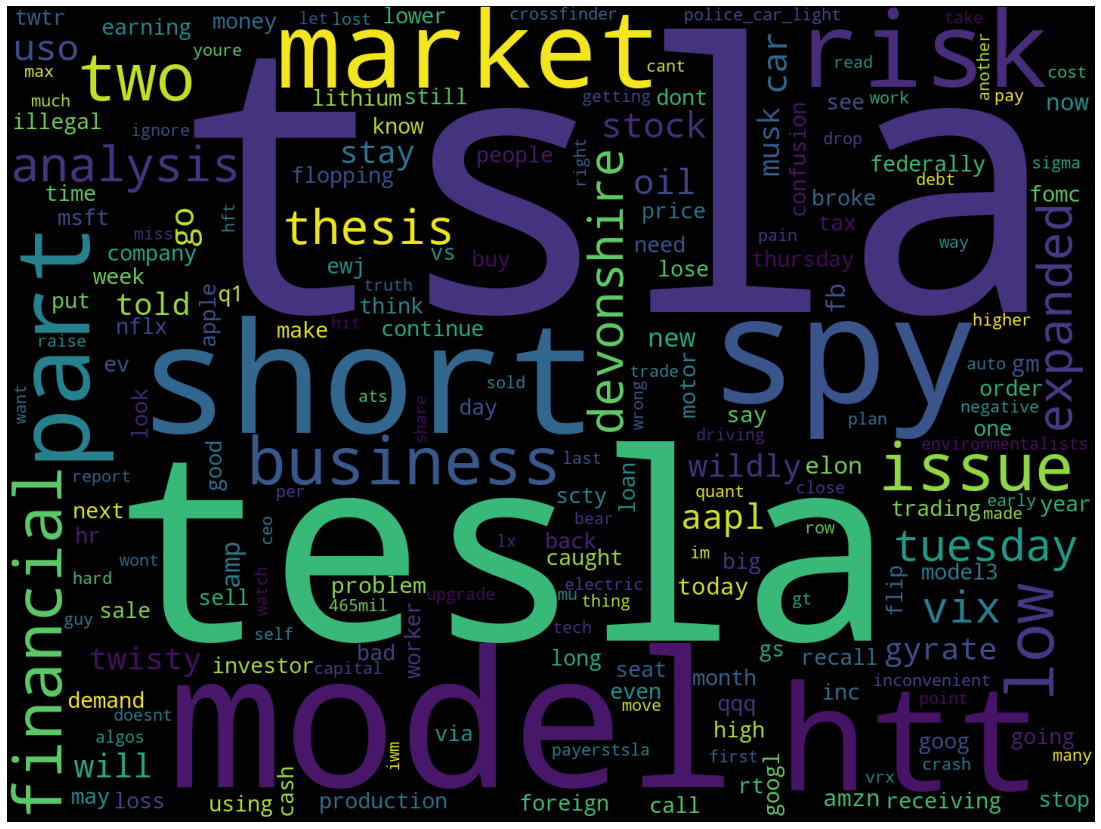

In [30]:
wc_plot(df[df["VADER_class"] == "NEGATIVE"])

## DistilBERT based sentimenal classification
Here we use the [flair](https://github.com/flairNLP/flair) package to make sentimental analysis, which is based on [the DistilBERT model](https://arxiv.org/abs/1910.01108), a state-of-the-art natural language processing (NLP) model to date. Comparing to VADER which is based on lexicon, DistilBERT and BERT are both deep learning models, which may capture more information through training. Here pre-trained models for English text classification is used.

In [31]:
# load the distilBERT model for sentimental analysis
%%capture
!pip install flair
import flair
sentiment_model = flair.models.TextClassifier.load('en-sentiment')

In [32]:
def get_DistilBERT_pred(tweet):
  sentence = flair.data.Sentence(tweet)
  sentiment_model.predict(sentence)
  try:
    return sentence.labels[0].score, sentence.labels[0].value
  except:
    return np.nan, np.nan

In [33]:
# this cell takes a long time to run (sometimes > 50 minutes). please be patient...
df["DistilBERT_prob"], df["DistilBERT_class"] = zip(*df["cleaned"].map(get_DistilBERT_pred))

In [34]:
df[df["VADER_class"] == df["DistilBERT_class"]]

,Date,Hour,Tweet content,cleaned,VADER_score,VADER_class,DistilBERT_prob,DistilBERT_class
1,2016-06-15,11:47,RT @markbspiegel: People really like to be abl...,People really like to be able to go 20-30 mile...,0.6901,POSITIVE,0.999722,POSITIVE
6,2016-06-15,11:43,RT @markbspiegel: People really like to be abl...,People really like to be able to go 20-30 mile...,0.6901,POSITIVE,0.999722,POSITIVE
7,2016-06-15,11:39,Here's why a #TeslaModelS #electricvehicle is ...,Here's why a TeslaModelS electricvehicle is be...,0.4404,POSITIVE,0.894489,POSITIVE
16,2016-06-15,11:24,Battery technology is changing energy sector i...,Battery technology is changing energy sector i...,0.2732,POSITIVE,0.990884,POSITIVE
17,2016-06-15,11:23,"@beefnbunhou $TSLA limbo, I tried to short and...","TSLA limbo, I tried to short and was quickly s...",0.5719,POSITIVE,0.930078,POSITIVE
...,...,...,...,...,...,...,...,...
82467,2016-04-02,13:14,Why Tesla Motors Became the Most Important Sto...,Why Tesla Motors Became the Most Important Sto...,0.2716,POSITIVE,0.842269,POSITIVE
82471,2016-04-02,13:03,@AndreaSJames with $TSLA preorders now approac...,with TSLA preorders now approaching 250k does ...,-0.5411,NEGATIVE,0.890628,NEGATIVE
82472,2016-04-02,13:03,$TSLA will be interesting to see how long #bat...,TSLA will be interesting to see how long batte...,0.4019,POSITIVE,0.963607,POSITIVE
82473,2016-04-02,13:03,$TSLA will be interesting to see how long #bat...,TSLA will be interesting to see how long batte...,0.4019,POSITIVE,0.963607,POSITIVE


In [35]:
df_contradict = df[df["VADER_class"] != df["DistilBERT_class"]][df['VADER_class'] != "NEUTRAL"]
for i in df_contradict[["Tweet content", "VADER_class", "DistilBERT_class"]].iterrows():
  # if you want to see inconsistent classification, you can uncomment below...
  # print(i[1][0], "\nVADER_class: "+i[1][1], "\nDistilBERT_class: "+i[1][2])
  pass

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """Entry point for launching an IPython kernel.


In [36]:
# save the sentimental data to Google Drive
def save_sentiments(df, target_folder):
  df.to_csv(target_folder+code+"ALL.csv")
  df[["Date", "cleaned", "VADER_score", "VADER_class"]].to_csv(target_folder+code+"_VADER.csv")
  df[["Date", "cleaned", "DistilBERT_prob", "DistilBERT_class"]].to_csv(target_folder+code+"_DistilBERT.csv")

In [37]:
target_folder = "/content/drive/MyDrive/DeepLearningProject_StockPrice/"
save_sentiments(df, target_folder)

VADER_scores = df[["Date", "cleaned", "VADER_score", "VADER_class"]]
DistilBERT_scores = df[["Date", "cleaned", "DistilBERT_prob", "DistilBERT_class"]]

In [38]:
df[["Date", "cleaned", "VADER_score", "VADER_class"]]

,Date,cleaned,VADER_score,VADER_class
0,2016-06-15,TSLA:Tesla Partners Nordstrom to Open Gallery ...,0.0000,NEUTRAL
1,2016-06-15,People really like to be able to go 20-30 mile...,0.6901,POSITIVE
2,2016-06-15,Tesla Motors Inc TSLA Stock Rating Reaffirmed ...,0.0000,NEUTRAL
3,2016-06-15,TeslaMotorsInc Down More Than 10% in One Week ...,0.0000,NEUTRAL
4,2016-06-15,Pacific Crest Reiterates “Hold” Rating for Tes...,0.0000,NEUTRAL
...,...,...,...,...
82472,2016-04-02,TSLA will be interesting to see how long batte...,0.4019,POSITIVE
82473,2016-04-02,TSLA will be interesting to see how long batte...,0.4019,POSITIVE
82474,2016-04-02,This is one of the most relevant articles abou...,0.0000,NEUTRAL
82475,2016-04-02,"Getting 115,000 people to put down 1,000 for a...",0.4939,POSITIVE


NEGATIVE    47860
POSITIVE    34617
Name: DistilBERT_class, dtype: int64


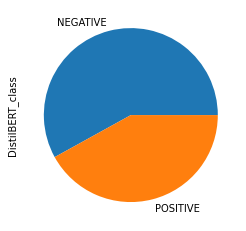

In [39]:
# what is different from DistilBERT based classifier is that it makes a binary rather than a 3-class classification as shown below
print(df['DistilBERT_class'].value_counts())
df['DistilBERT_class'].value_counts().plot(kind="pie")

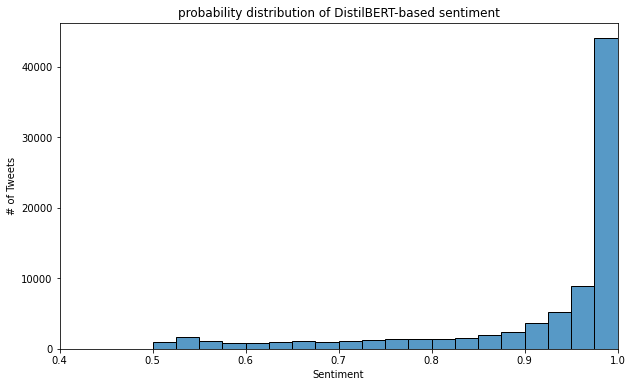

In [40]:
# also the sentiment score here is actually probability, so only those > 0.5 are considered, while most of the identified sentiment is larger than 0.9.
fig, ax = plt.subplots(figsize=(10,6))
# Plotting the sentiment scores
sns.histplot(df['DistilBERT_prob'], bins=20)
plt.title("probability distribution of DistilBERT-based sentiment")
ax.set_xlim([0.4,1])
plt.xlabel("Sentiment")
plt.ylabel("# of Tweets")
plt.show()

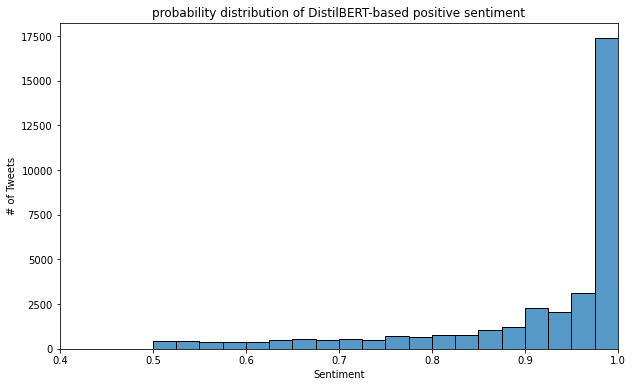

In [41]:
fig, ax = plt.subplots(figsize=(10,6))
# Plotting the sentiment scores
sns.histplot(df[df["DistilBERT_class"] == "POSITIVE"]['DistilBERT_prob'], bins=20)
plt.title("probability distribution of DistilBERT-based positive sentiment")
ax.set_xlim([0.4,1])
plt.xlabel("Sentiment")
plt.ylabel("# of Tweets")
plt.show()

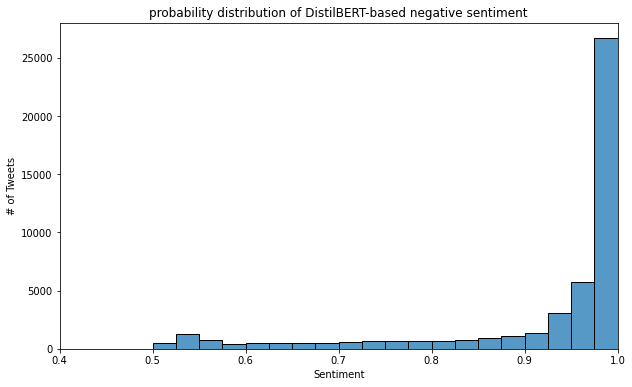

In [42]:
fig, ax = plt.subplots(figsize=(10,6))
# Plotting the sentiment scores
sns.histplot(df[df["DistilBERT_class"] == "NEGATIVE"]['DistilBERT_prob'], bins=20)
plt.title("probability distribution of DistilBERT-based negative sentiment")
ax.set_xlim([0.4,1])
plt.xlabel("Sentiment")
plt.ylabel("# of Tweets")
plt.show()

### Visualisation of Negative Sentiments

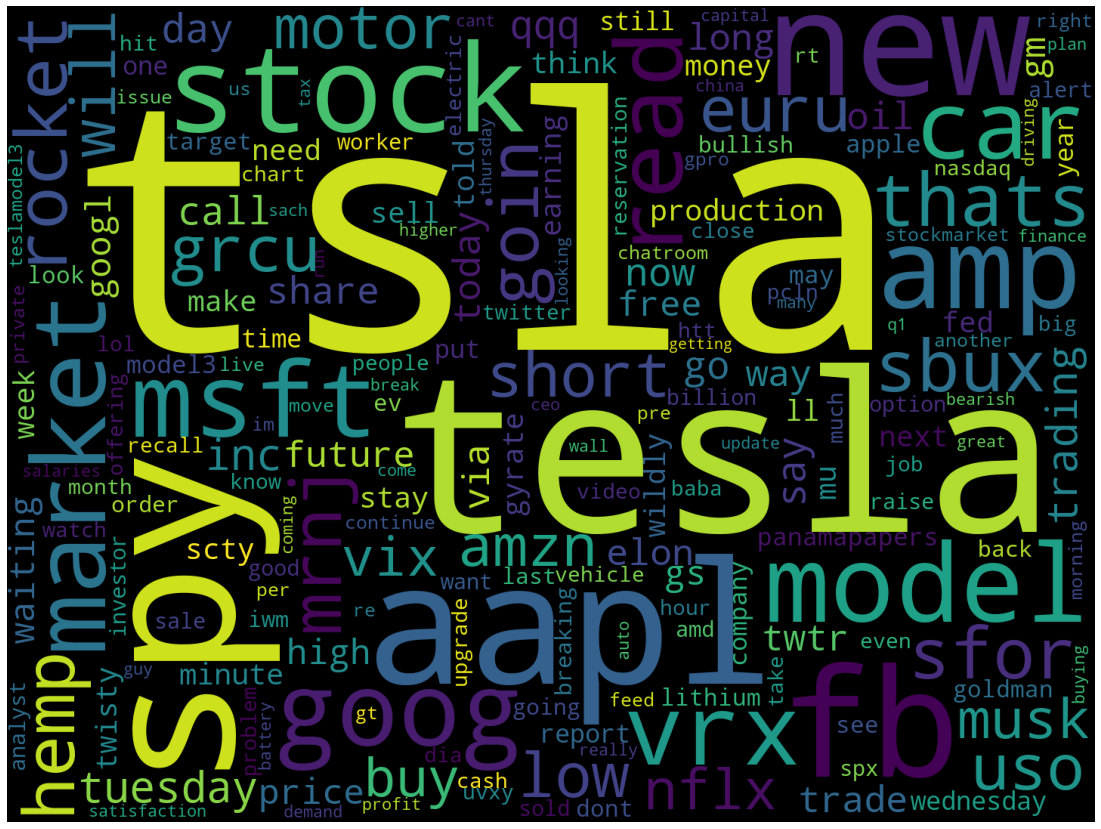

In [43]:
wc_plot(df[df["DistilBERT_class"]=="NEGATIVE"])

### Visualisation of Positive Sentiments

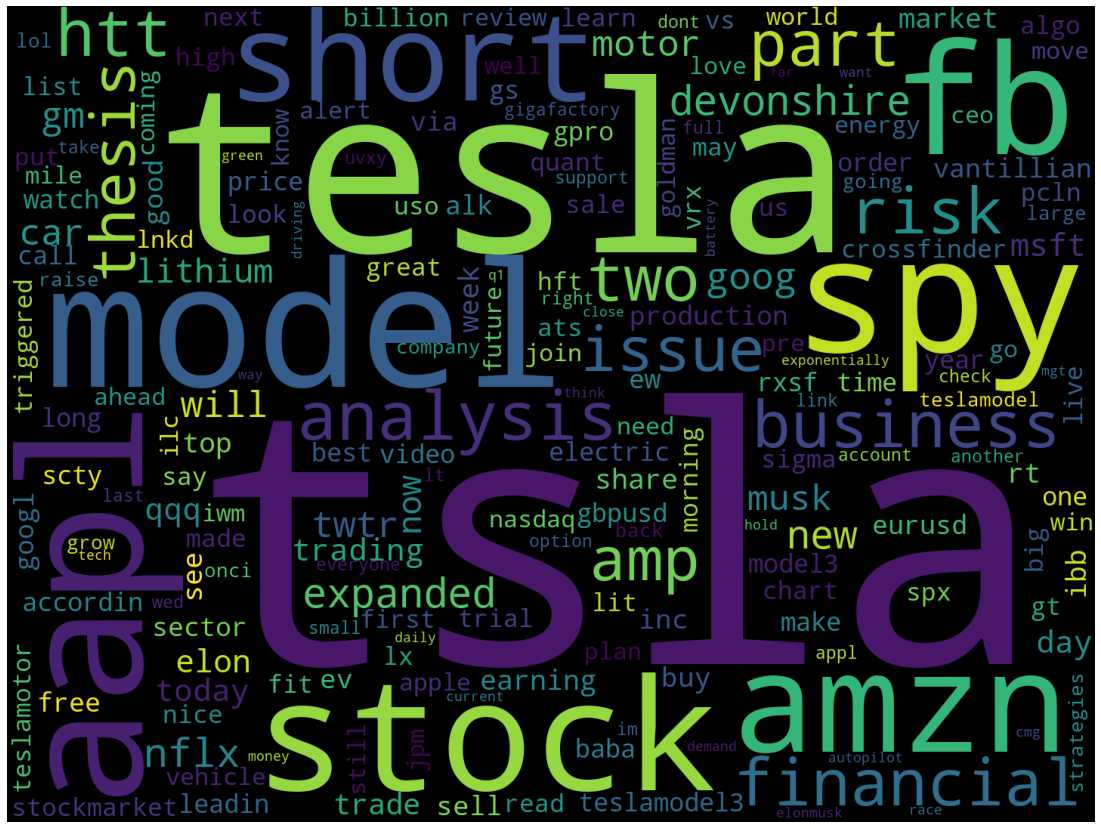

In [44]:
wc_plot(df[df["DistilBERT_class"]=="POSITIVE"])

# Calculate Daily Sentiments

## VADER

In [45]:
def create_feature_set(df, model_type):
  
  # data preproccessing for the DistilBERT model
  if model_type == "DistilBERT":
    df["DistilBERT_score"] = df.apply(lambda x: 2*(x["DistilBERT_prob"]-0.5) if x["DistilBERT_class"] == "POSITIVE" else -2*(x["DistilBERT_prob"]-0.5), axis = 1)

  # acquire column keys
  class_label = model_type+"_class"
  class_score = model_type+"_score"
  
  # count the number of tweets of different sentiment classes
  features_df = df.groupby(['Date', class_label], as_index=False).size().pivot("Date", columns=class_label, values="size").fillna(0)
  
  # acquire sentiment class names
  class_labels = [feature for feature in features_df.columns]
  # calculate the sum of tweets
  features_df["NumTweet"] = features_df.sum(axis=1)
  
  # calculate percentages of each sentiment class
  for label in class_labels:
    percetage_label = label+"_percentage"
    features_df[percetage_label] = features_df[label]/features_df["NumTweet"]
  
  # calculate average and sum score of sentiment classification
  features_df = features_df.join(df.groupby(df.Date).mean()[class_score]).rename(columns={class_score: "avg_score"})
  features_df = features_df.join(df.groupby(df.Date).sum()[class_score]).rename(columns={class_score: "sum_score"})

  # add prefix according to model type
  features_df = features_df.add_prefix(model_type+"_")

  # check the dataset again
  check(features_df)

  return features_df


In [46]:
VADER_scores = create_feature_set(df, "VADER")


Checking the dataset now...

Dataset size: (70, 9)

Checking variables now...
<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 2016-04-02 to 2016-06-15
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   VADER_NEGATIVE             70 non-null     int64  
 1   VADER_NEUTRAL              70 non-null     int64  
 2   VADER_POSITIVE             70 non-null     int64  
 3   VADER_NumTweet             70 non-null     int64  
 4   VADER_NEGATIVE_percentage  70 non-null     float64
 5   VADER_NEUTRAL_percentage   70 non-null     float64
 6   VADER_POSITIVE_percentage  70 non-null     float64
 7   VADER_avg_score            70 non-null     float64
 8   VADER_sum_score            70 non-null     float64
dtypes: float64(5), int64(4)
memory usage: 8.0+ KB
None

Checking null values now...
No missing data

Checking duplicate values now...
No duplicates data
Starting time: 2021-10-27 13:50:12

F

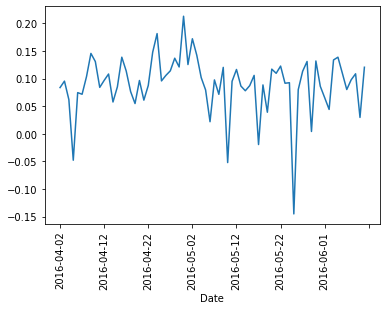

In [47]:
# visualise the sentimental changes
VADER_scores["VADER_avg_score"].plot(rot=90)

In [48]:
DistilBERT_scores = create_feature_set(df, "DistilBERT")


Checking the dataset now...

Dataset size: (70, 7)

Checking variables now...
<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 2016-04-02 to 2016-06-15
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   DistilBERT_NEGATIVE             70 non-null     int64  
 1   DistilBERT_POSITIVE             70 non-null     int64  
 2   DistilBERT_NumTweet             70 non-null     int64  
 3   DistilBERT_NEGATIVE_percentage  70 non-null     float64
 4   DistilBERT_POSITIVE_percentage  70 non-null     float64
 5   DistilBERT_avg_score            70 non-null     float64
 6   DistilBERT_sum_score            70 non-null     float64
dtypes: float64(4), int64(3)
memory usage: 6.9+ KB
None

Checking null values now...
No missing data

Checking duplicate values now...
No duplicates data
Starting time: 2021-10-27 13:50:13

Finishing time: 2021-10-27 13:50:13
Finished within 0.01340818405151

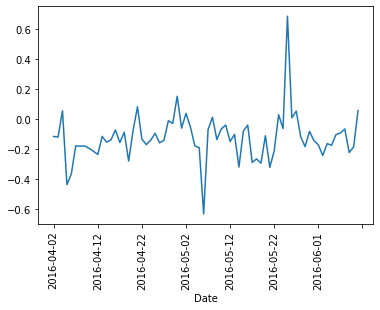

In [49]:
# visualise the sentimental changes
DistilBERT_scores["DistilBERT_avg_score"].plot(rot=90)

# Acquiring stock price data

In [50]:
def add_stock_data(feature_df):
  stock_prices = pd.DataFrame.from_dict(get_stock_information(code, "TIME_SERIES_DAILY")['Time Series (Daily)']).T.astype(float)[::-1]
  stock_prices.index = pd.to_datetime(stock_prices.index)
  stock_prices = stock_prices[DistilBERT_scores.index.min():DistilBERT_scores.index.max()]
  feature_df.index = pd.to_datetime(feature_df.index)
  feature_df = feature_df.join(stock_prices)
  feature_df = feature_df.fillna(method="ffill").dropna()
  feature_df["4. close"].plot(rot=90)
  check(feature_df)
  return feature_df

Thus, we construct two feature matrix here. The output should be the closing prices of the next trading day.

In [51]:
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import MinMaxScaler 

def X_y_split(feature_df):

  X = feature_df[:len(feature_df)-1]
  X_scaler = MinMaxScaler()
  X = X_scaler.fit_transform(X)
  X = X.reshape(X.shape[0], X.shape[1], 1)

  y = pd.DataFrame(feature_df[1:]["4. close"])
  y_scaler = MinMaxScaler()
  y = y_scaler.fit_transform(y)

  return X, y, y_scaler

# Build a LSTM model for time-series prediction

In [52]:
# this is just a typical LSTM.... not very surprising
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def build_model(X_train_shape):
  model = Sequential()
  number_units = 9
  dropout_fraction = 0.2

  # Layer 1
  model.add(LSTM(
    units=number_units,
    return_sequences=True,
    input_shape=(X_train_shape[1], 1)))
  model.add(Dropout(dropout_fraction))

  # Layer 2
  # The return_sequences parameter needs to set to True every time we add a new LSTM layer, excluding the final layer.
  model.add(LSTM(units=number_units, return_sequences=True))
  model.add(Dropout(dropout_fraction))

  # Layer 3
  model.add(LSTM(units=number_units))
  model.add(Dropout(dropout_fraction))

  # Output layer
  model.add(Dense(1))

  model.compile(optimizer="adam", loss="mean_squared_error")
  print(model.summary())

  return model

In [53]:
from sklearn import metrics

def model_training(feature_df):
  
  # building training and test dataset
  print("\n\nbuilding training and test dataset...")
  X, y, y_scaler = X_y_split(feature_df)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

  # training the model for 100 epochs
  print("\n\ntraining the model for 100 epochs...")
  model = build_model(X_train.shape)
  model.fit(X_train, y_train, epochs=100, shuffle=False, batch_size=5, verbose=1)

  # evaluating the model with loss
  print("\n\nevaluating the model with loss")
  model.evaluate(X_test, y_test)

  # calculate predicted values in test dataset
  print("\n\ncalculate predicted values in test dataset...")
  predicted = model.predict(X_test)
  print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, predicted)))
  print('R-squared :', metrics.r2_score(y_test, predicted))

  # rescale y values to real scale
  print("\n\nrescale y values to real scale in test dataset...")
  predicted_prices = y_scaler.inverse_transform(predicted)
  real_prices = y_scaler.inverse_transform(y_test.reshape(-1, 1))
  stocks = pd.DataFrame({
    "Real": real_prices.ravel(),
    "Predicted": predicted_prices.ravel()
    }, index = df.index[-len(real_prices): ]) 
  
  print("\n\ndisplaying prediction results in test dataset...")
  stocks.plot(kind="line")
  print(stocks)

  return model


Checking the dataset now...

Dataset size: (68, 12)

Checking variables now...
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 68 entries, 2016-04-04 to 2016-06-15
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   DistilBERT_NEGATIVE             68 non-null     int64  
 1   DistilBERT_POSITIVE             68 non-null     int64  
 2   DistilBERT_NumTweet             68 non-null     int64  
 3   DistilBERT_NEGATIVE_percentage  68 non-null     float64
 4   DistilBERT_POSITIVE_percentage  68 non-null     float64
 5   DistilBERT_avg_score            68 non-null     float64
 6   DistilBERT_sum_score            68 non-null     float64
 7   1. open                         68 non-null     float64
 8   2. high                         68 non-null     float64
 9   3. low                          68 non-null     float64
 10  4. close                        68 non-null     float64
 11 

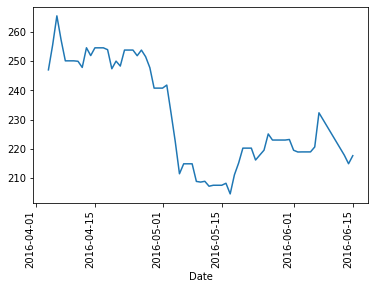

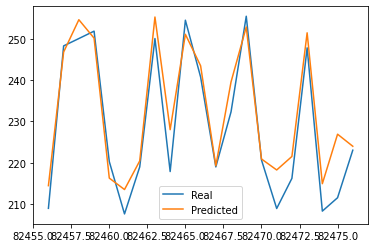

In [54]:
distilBERT_model = model_training(add_stock_data(DistilBERT_scores))


Checking the dataset now...

Dataset size: (68, 14)

Checking variables now...
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 68 entries, 2016-04-04 to 2016-06-15
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   VADER_NEGATIVE             68 non-null     int64  
 1   VADER_NEUTRAL              68 non-null     int64  
 2   VADER_POSITIVE             68 non-null     int64  
 3   VADER_NumTweet             68 non-null     int64  
 4   VADER_NEGATIVE_percentage  68 non-null     float64
 5   VADER_NEUTRAL_percentage   68 non-null     float64
 6   VADER_POSITIVE_percentage  68 non-null     float64
 7   VADER_avg_score            68 non-null     float64
 8   VADER_sum_score            68 non-null     float64
 9   1. open                    68 non-null     float64
 10  2. high                    68 non-null     float64
 11  3. low                     68 non-null     float64
 12  4. close

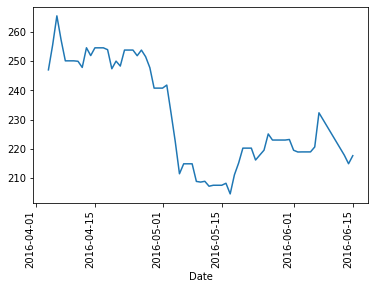

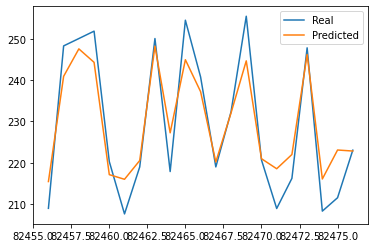

In [55]:
VADER_model = model_training(add_stock_data(VADER_scores))